# BDAPP — CNN training on Google Colab (GPU)

This notebook trains the flow-to-image CNN (ResNet18) for the BDAPP project, mirroring
`scripts/8_train_cnn.py` and `scripts/flow_image_dataset.py` exactly (same hyperparameters,
same class-weighting, same early-stopping metric), so results are directly comparable to
what the local pipeline documents.

**Why Colab instead of the local machine:** the laptop's NVIDIA GPU needs a newer kernel
(`7.0.0-31-generic`) than the one currently pinned as stable (`6.14.0-37-generic` +
`amdgpu.runpm=0`), after an earlier kernel (6.17) caused boot-time crashes in `amdgpu`
initialization. Booting the newer kernel to get CUDA locally risks reproducing that same
class of failure, so training runs here instead, on a free Colab GPU (T4), while the local
machine stays on its stable configuration for everything else in the pipeline.

**Before running:** `Runtime -> Change runtime type -> Hardware accelerator -> GPU (T4)`,
then `Runtime -> Run all` (or run cells top to bottom).

**What you need to upload:** a zip of `data/processed/flow_images/` from the local project
(the 5 files: `train_grids.npy`, `train_labels.npy`, `test_grids.npy`, `test_labels.npy`,
`encoding_metadata.joblib` — about 74 MB total, produced by `7_flow_to_image_encoding.py`).

**Long-run safety:** the full training run is estimated at several hours (extrapolated from
a --smoke-test-equivalent run: ~15s for 5,000 rows on a T4 -> ~30-35 min/epoch on the full
~690K-row train set). `/content/` is wiped if the Colab runtime disconnects, so this notebook
mounts your Google Drive and saves the checkpoint (and every other output) there every time
validation macro-F1 improves -- if the session disconnects mid-run, the best checkpoint up to
that point is safe on Drive (the training loop itself does not auto-resume from a checkpoint;
you'd restart from epoch 1 in a fresh session, but nothing already-saved is lost).


## 1. Check GPU

In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected -- go to Runtime > Change runtime type > GPU (T4), then re-run.")

!nvidia-smi


CUDA available: True
GPU: NVIDIA L4
Tue Sep 22 12:08:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   33C    P8             14W /   72W |       3MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------

## 2. Mount Google Drive (checkpoints saved here survive a disconnect)

You'll get a popup asking you to authorize access to your Google Drive -- approve it. All
outputs (model checkpoint, training log, plots, reports) will be written to
`My Drive/BDAPP_cnn_results/` as training progresses, not just to Colab's ephemeral `/content/`.

In [2]:
from google.colab import drive
import os

drive.mount("/content/drive")

DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/BDAPP_cnn_results"
os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)
print("Outputs will be saved to:", DRIVE_OUTPUT_DIR)


Mounted at /content/drive
Outputs will be saved to: /content/drive/MyDrive/BDAPP_cnn_results


## 3. Load the encoded data

`google.colab.files.upload()`/`download()` need Colab's browser frontend to render a picker/trigger a download, which does not work reliably from the VS Code Colab extension (the cell can hang waiting for a dialog that never appears). This notebook reads the data from your mounted Drive instead.

**Before running the next cell:** on your local machine, zip the folder --

```bash
cd BDAPP_project/data/processed
zip -r flow_images.zip flow_images/
```

-- then upload `flow_images.zip` to your Google Drive (via the Drive website or desktop sync app), into a folder of your choice. Set `DRIVE_ZIP_PATH` below to match where you put it (default assumes `My Drive/BDAPP_data/flow_images.zip`).

In [3]:
import os

# Adjust this to wherever you uploaded flow_images.zip in your Google Drive.
DRIVE_ZIP_PATH = "/content/drive/MyDrive/BDAPP_data/flow_images.zip"

if not os.path.exists(DRIVE_ZIP_PATH):
    raise FileNotFoundError(
        f"{DRIVE_ZIP_PATH} not found. Upload flow_images.zip to your Google Drive first "
        "(see the markdown cell above), then fix DRIVE_ZIP_PATH to match its path."
    )
print("Found:", DRIVE_ZIP_PATH)

Found: /content/drive/MyDrive/BDAPP_data/flow_images.zip


In [4]:
import zipfile

with zipfile.ZipFile(DRIVE_ZIP_PATH, "r") as zf:
    zf.extractall(".")

# Handle either flow_images.zip containing a top-level flow_images/ folder,
# or the 5 files directly at the zip root.
if os.path.isdir("flow_images"):
    DATA_DIR = "flow_images"
else:
    DATA_DIR = "."

print("Data dir:", DATA_DIR)
print(os.listdir(DATA_DIR))

Data dir: flow_images
['test_grids.npy', 'train_labels.npy', 'test_labels.npy', 'train_grids.npy', 'encoding_metadata.joblib']


## 4. FlowImageDataset

Identical to `scripts/flow_image_dataset.py` -- same nearest-neighbor upscale,
same ImageNet normalization (this run also uses ImageNet-pretrained ResNet18).

In [5]:
import cv2
import numpy as np
from torch.utils.data import Dataset

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(3, 1, 1)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(3, 1, 1)


class FlowImageDataset(Dataset):
    """Wraps a (N, grid_size, grid_size) uint8 array of flow-image grids and a
    (N,) array of integer labels. Each sample is upscaled to cnn_input_size x
    cnn_input_size with NEAREST-NEIGHBOR interpolation only (never bilinear/
    bicubic -- see the project's Notion Work log, Section 13, for why) and
    normalized on the fly."""

    def __init__(self, grids: np.ndarray, labels: np.ndarray, cnn_input_size: int = 224) -> None:
        if len(grids) != len(labels):
            raise ValueError(f"grids and labels must have the same length, got {len(grids)} and {len(labels)}")
        self.grids = grids
        self.labels = labels
        self.cnn_input_size = cnn_input_size

    def __len__(self) -> int:
        return len(self.grids)

    def __getitem__(self, idx: int):
        grid = self.grids[idx]
        upscaled = cv2.resize(grid, (self.cnn_input_size, self.cnn_input_size), interpolation=cv2.INTER_NEAREST)
        img = upscaled.astype(np.float32) / 255.0
        img = np.repeat(img[np.newaxis, :, :], 3, axis=0)
        img = (img - IMAGENET_MEAN) / IMAGENET_STD
        label = int(self.labels[idx])
        return torch.from_numpy(img), label


## 5. Hyperparameters

Identical to `scripts/config.py`'s `CNN_*` constants, so this run stays comparable to what's
documented in the project's Notion Work log and README.

In [6]:
CNN_INPUT_SIZE = 224
CNN_VAL_SIZE = 0.10
CNN_BATCH_SIZE = 128
CNN_NUM_WORKERS = 2          # Colab: 2 is usually safer than 4 (fewer CPU cores available)
CNN_LEARNING_RATE = 1e-4
CNN_WEIGHT_DECAY = 1e-4
CNN_MAX_EPOCHS = 30
CNN_EARLY_STOPPING_PATIENCE = 5
RANDOM_STATE = 42

# Optional quick sanity check before the full run (mirrors --smoke-test locally).
# Set to True once to confirm everything runs end-to-end on Colab's GPU, then
# set back to False and re-run from here for the real training run.
SMOKE_TEST = False
if SMOKE_TEST:
    CNN_MAX_EPOCHS = 1


## 6. Model, loss, training/eval helpers (same logic as `8_train_cnn.py`)

In [7]:
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.utils.class_weight import compute_class_weight


def build_model(n_classes: int) -> nn.Module:
    """ImageNet-pretrained ResNet18, final FC layer replaced for n_classes.
    Fine-tuned end-to-end (not frozen)."""
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    return model


def compute_full_class_weights(y: np.ndarray, n_classes: int) -> np.ndarray:
    """Like class_weight='balanced', but tolerant of a class missing from y
    (weight defaults to 1.0) -- relevant if SMOKE_TEST truncation drops a rare class."""
    present_classes = np.unique(y)
    weights_present = compute_class_weight(class_weight="balanced", classes=present_classes, y=y)
    weights = np.ones(n_classes, dtype=np.float32)
    for cls, w in zip(present_classes, weights_present):
        weights[cls] = w
    return weights


def run_epoch(model, loader, criterion, device, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, n_samples = 0.0, 0
    all_true, all_pred = [], []

    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if is_train:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            n_samples += batch_size

            preds = outputs.argmax(dim=1)
            all_true.extend(labels.cpu().numpy().tolist())
            all_pred.extend(preds.cpu().numpy().tolist())

    return total_loss / n_samples, np.array(all_true), np.array(all_pred)


## 7. Load data, stratified train/val split (test stays untouched)

In [8]:
import joblib
import os
from sklearn.model_selection import train_test_split

metadata = joblib.load(os.path.join(DATA_DIR, "encoding_metadata.joblib"))
label_encoder = metadata["label_encoder"]
class_names = list(label_encoder.classes_)
n_classes = len(class_names)
print(f"{n_classes} classes: {class_names}")

train_grids_full = np.load(os.path.join(DATA_DIR, "train_grids.npy"))
train_labels_full = np.load(os.path.join(DATA_DIR, "train_labels.npy"))
test_grids = np.load(os.path.join(DATA_DIR, "test_grids.npy"))
test_labels = np.load(os.path.join(DATA_DIR, "test_labels.npy"))
print(f"train: {train_grids_full.shape}  test: {test_grids.shape}")

if SMOKE_TEST:
    train_grids_full, train_labels_full = train_grids_full[:5000], train_labels_full[:5000]
    test_grids, test_labels = test_grids[:1000], test_labels[:1000]
    print(f"[SMOKE_TEST] truncated -- train: {train_grids_full.shape}  test: {test_grids.shape}")

class_counts = np.bincount(train_labels_full, minlength=n_classes)
can_stratify = class_counts[class_counts > 0].min() >= 2

train_grids, val_grids, train_labels, val_labels = train_test_split(
    train_grids_full, train_labels_full,
    test_size=CNN_VAL_SIZE, random_state=RANDOM_STATE,
    stratify=train_labels_full if can_stratify else None,
)
print(f"Train: {len(train_grids):,}  Val: {len(val_grids):,}  Test: {len(test_grids):,}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

from torch.utils.data import DataLoader

train_ds = FlowImageDataset(train_grids, train_labels, CNN_INPUT_SIZE)
val_ds = FlowImageDataset(val_grids, val_labels, CNN_INPUT_SIZE)
test_ds = FlowImageDataset(test_grids, test_labels, CNN_INPUT_SIZE)

train_loader = DataLoader(train_ds, batch_size=CNN_BATCH_SIZE, shuffle=True,
                           num_workers=CNN_NUM_WORKERS, pin_memory=(device.type == "cuda"))
val_loader = DataLoader(val_ds, batch_size=CNN_BATCH_SIZE, shuffle=False,
                         num_workers=CNN_NUM_WORKERS, pin_memory=(device.type == "cuda"))
test_loader = DataLoader(test_ds, batch_size=CNN_BATCH_SIZE, shuffle=False,
                          num_workers=CNN_NUM_WORKERS, pin_memory=(device.type == "cuda"))


/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


11 classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'PortScan', 'SSH-Patator', 'Web Attack']
train: (690555, 8, 8)  test: (514519, 8, 8)
Train: 621,499  Val: 69,056  Test: 514,519
Using device: cuda


## 8. Train (early stopping on validation macro-F1, resumable across sessions)

Checkpoints the best model to Drive every time val macro-F1 improves, and rewrites the
training-log CSV to Drive **after every single epoch** (not just at the end) -- both matter
because Colab's free tier disconnects after a few hours, mid-epoch-range, with no warning.

**Resuming:** if a checkpoint already exists in `DRIVE_OUTPUT_DIR` (e.g. from a previous
session that got cut off), this cell picks up from the epoch right after it, instead of
restarting at epoch 1 and wasting the hours already spent. Just re-run the whole notebook
(GPU check -> Drive mount -> re-upload data -> this cell) in a new Colab session; you do not
need to change anything for the resume to kick in. Set `RESUME = False` below only if you
want to intentionally discard the existing checkpoint and start over.

In [9]:
import time
import csv
import pandas as pd
from sklearn.metrics import f1_score

RESUME = True  # set False to force a fresh start from epoch 1 (discards the saved checkpoint's progress)

MODEL_PATH = os.path.join(DRIVE_OUTPUT_DIR, "cnn_resnet18_best.pt")
TRAINING_LOG_CSV = os.path.join(DRIVE_OUTPUT_DIR, "cnn_training_log.csv")

model = build_model(n_classes).to(device)

class_weights = compute_full_class_weights(train_labels, n_classes)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)
print("Class weights (balanced):", dict(zip(class_names, class_weights.round(3))))

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=CNN_LEARNING_RATE, weight_decay=CNN_WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

start_epoch = 1
best_val_f1 = -1.0
epochs_without_improvement = 0
log_rows = []

if RESUME and os.path.exists(MODEL_PATH):
    print(f"Found existing checkpoint at {MODEL_PATH} -- resuming instead of restarting.")
    checkpoint = torch.load(MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    if "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    if "scheduler_state_dict" in checkpoint:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    best_val_f1 = checkpoint["val_macro_f1"]
    start_epoch = checkpoint["epoch"] + 1

    if os.path.exists(TRAINING_LOG_CSV):
        prev_log = pd.read_csv(TRAINING_LOG_CSV)
        log_rows = prev_log.to_dict("records")
        last_logged_epoch = int(prev_log["epoch"].max())
        best_epoch = int(prev_log.loc[prev_log["val_macro_f1"].idxmax(), "epoch"])
        epochs_without_improvement = last_logged_epoch - best_epoch
    else:
        # Log wasn't written yet (e.g. this checkpoint is from before the log-every-epoch
        # fix) -- we can't recover the exact non-improvement streak, so restart the patience
        # counter at 0. Slightly generous (won't stop a bit too early), never unsafe.
        print("  (no training log found on Drive -- early-stopping patience counter reset to 0)")

    print(f"  Resuming from epoch {start_epoch}, best val macro-F1 so far = {best_val_f1:.4f} "
          f"(epochs without improvement: {epochs_without_improvement})")
else:
    print("Starting fresh from epoch 1.")

print(f"Training up to epoch {CNN_MAX_EPOCHS} (patience={CNN_EARLY_STOPPING_PATIENCE}, metric=val macro-F1)...\n")
for epoch in range(start_epoch, CNN_MAX_EPOCHS + 1):
    start = time.time()

    train_loss, _, _ = run_epoch(model, train_loader, criterion, device, optimizer)
    val_loss, val_true, val_pred = run_epoch(model, val_loader, criterion, device, optimizer=None)

    val_accuracy = float((val_true == val_pred).mean())
    val_macro_f1 = f1_score(val_true, val_pred, average="macro", zero_division=0)
    scheduler.step(val_macro_f1)
    current_lr = optimizer.param_groups[0]["lr"]

    elapsed = time.time() - start
    print(f"Epoch {epoch:3d}/{CNN_MAX_EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
          f"val_acc={val_accuracy:.4f} | val_macro_f1={val_macro_f1:.4f} | lr={current_lr:.2e} | {elapsed:.1f}s")

    log_rows.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
                      "val_accuracy": val_accuracy, "val_macro_f1": val_macro_f1, "lr": current_lr})

    # Rewrite the full log to Drive after EVERY epoch (cheap -- a few KB), so a disconnect
    # never loses more than the epoch that was in progress.
    with open(TRAINING_LOG_CSV, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(log_rows[0].keys()))
        writer.writeheader()
        writer.writerows(log_rows)

    if val_macro_f1 > best_val_f1:
        best_val_f1 = val_macro_f1
        epochs_without_improvement = 0
        torch.save({"model_state_dict": model.state_dict(),
                     "optimizer_state_dict": optimizer.state_dict(),
                     "scheduler_state_dict": scheduler.state_dict(),
                     "epoch": epoch, "val_macro_f1": val_macro_f1,
                     "class_names": class_names}, MODEL_PATH)
        print(f"  -> New best val macro-F1 ({val_macro_f1:.4f}). Saved.")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= CNN_EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping: no improvement for {CNN_EARLY_STOPPING_PATIENCE} epochs "
                  f"(best={best_val_f1:.4f} at epoch {epoch - epochs_without_improvement}).")
            break

print("Training log saved to", TRAINING_LOG_CSV)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 234MB/s]


Class weights (balanced): {'BENIGN': np.float32(0.179), 'Bot': np.float32(40.271), 'DDoS': np.float32(0.613), 'DoS GoldenEye': np.float32(7.629), 'DoS Hulk': np.float32(0.454), 'DoS Slowhttptest': np.float32(15.011), 'DoS slowloris': np.float32(14.573), 'FTP-Patator': np.float32(13.232), 'PortScan': np.float32(0.865), 'SSH-Patator': np.float32(24.374), 'Web Attack': np.float32(36.617)}
Found existing checkpoint at /content/drive/MyDrive/BDAPP_cnn_results/cnn_resnet18_best.pt -- resuming instead of restarting.
  (no training log found on Drive -- early-stopping patience counter reset to 0)
  Resuming from epoch 9, best val macro-F1 so far = 0.8928 (epochs without improvement: 0)
Training up to epoch 30 (patience=5, metric=val macro-F1)...

Epoch   9/30 | train_loss=0.0432 | val_loss=0.0347 | val_acc=0.9798 | val_macro_f1=0.9037 | lr=1.00e-04 | 945.6s
  -> New best val macro-F1 (0.9037). Saved.
Epoch  10/30 | train_loss=0.0389 | val_loss=0.0368 | val_acc=0.9784 | val_macro_f1=0.8960 | lr

## 9. Training curves

Mounted at /content/drive
Device: cuda
Recargadas 22 filas del log de entrenamiento.
Mejor checkpoint: época 28, val macro-F1=0.9285


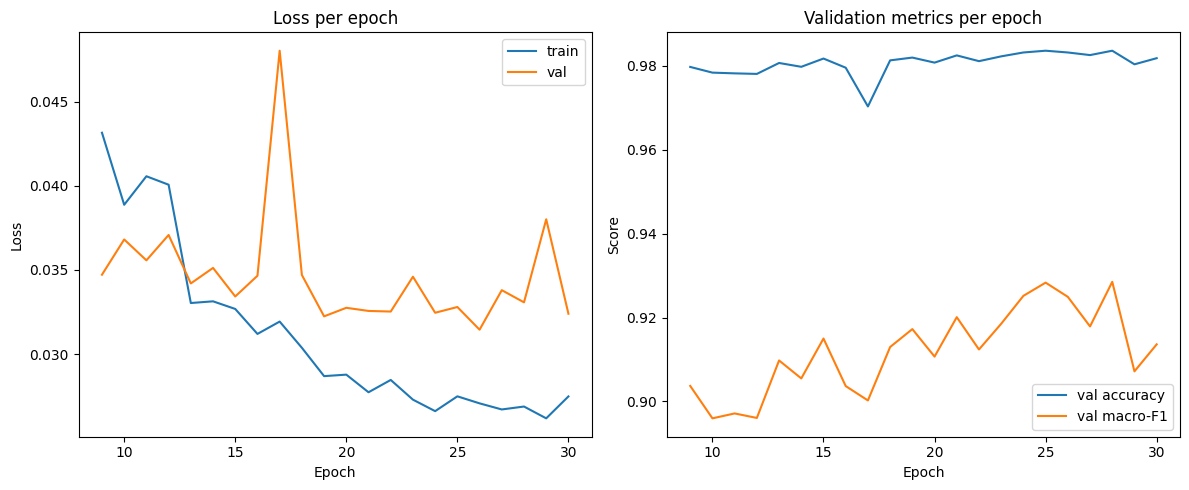

Saved to /content/drive/MyDrive/BDAPP_cnn_results/cnn_training_curves.png


In [5]:
# --- Celda de recuperación: reconstruye el estado sin re-entrenar ---
import os
import torch
import pandas as pd
import numpy as np
import joblib
from google.colab import drive

drive.mount("/content/drive")

DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/BDAPP_cnn_results"
MODEL_PATH = os.path.join(DRIVE_OUTPUT_DIR, "cnn_resnet18_best.pt")
TRAINING_LOG_CSV = os.path.join(DRIVE_OUTPUT_DIR, "cnn_training_log.csv")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

log_rows = pd.read_csv(TRAINING_LOG_CSV).to_dict("records")
print(f"Recargadas {len(log_rows)} filas del log de entrenamiento.")

checkpoint = torch.load(MODEL_PATH, map_location=device)
class_names = checkpoint["class_names"]
n_classes = len(class_names)
print(f"Mejor checkpoint: época {checkpoint['epoch']}, val macro-F1={checkpoint['val_macro_f1']:.4f}")

# Graph training curves:

epochs_ran = [r["epoch"] for r in log_rows]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(epochs_ran, [r["train_loss"] for r in log_rows], label="train")
axes[0].plot(epochs_ran, [r["val_loss"] for r in log_rows], label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss per epoch"); axes[0].legend()

axes[1].plot(epochs_ran, [r["val_accuracy"] for r in log_rows], label="val accuracy")
axes[1].plot(epochs_ran, [r["val_macro_f1"] for r in log_rows], label="val macro-F1")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score"); axes[1].set_title("Validation metrics per epoch"); axes[1].legend()

plt.tight_layout()
TRAINING_CURVES_PNG = os.path.join(DRIVE_OUTPUT_DIR, "cnn_training_curves.png")
fig.savefig(TRAINING_CURVES_PNG, dpi=150)
plt.show()
print("Saved to", TRAINING_CURVES_PNG)


## 10. Final evaluation on the untouched test set (best checkpoint)

In [8]:
# --- Reconstruir run_epoch, FlowImageDataset y test_loader ---
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# --- Re-extraer los datos desde Drive (el /content/ efímero se perdió) ---
import zipfile

DRIVE_ZIP_PATH = "/content/drive/MyDrive/BDAPP_data/flow_images.zip"  # ajusta si la pusiste en otra ruta

with zipfile.ZipFile(DRIVE_ZIP_PATH, "r") as zf:
    zf.extractall(".")

DATA_DIR = "flow_images" if os.path.isdir("flow_images") else "."
print("Data dir:", DATA_DIR)
print(os.listdir(DATA_DIR))

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(3, 1, 1)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(3, 1, 1)

class FlowImageDataset(Dataset):
    def __init__(self, grids, labels, cnn_input_size=224):
        self.grids = grids
        self.labels = labels
        self.cnn_input_size = cnn_input_size

    def __len__(self):
        return len(self.grids)

    def __getitem__(self, idx):
        grid = self.grids[idx]
        upscaled = cv2.resize(grid, (self.cnn_input_size, self.cnn_input_size), interpolation=cv2.INTER_NEAREST)
        img = upscaled.astype(np.float32) / 255.0
        img = np.repeat(img[np.newaxis, :, :], 3, axis=0)
        img = (img - IMAGENET_MEAN) / IMAGENET_STD
        label = int(self.labels[idx])
        return torch.from_numpy(img), label


def run_epoch(model, loader, criterion, device, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, n_samples = 0.0, 0
    all_true, all_pred = [], []

    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            if is_train:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if is_train:
                loss.backward()
                optimizer.step()
            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            n_samples += batch_size
            preds = outputs.argmax(dim=1)
            all_true.extend(labels.cpu().numpy().tolist())
            all_pred.extend(preds.cpu().numpy().tolist())

    return total_loss / n_samples, np.array(all_true), np.array(all_pred)


# --- Recargar los grids/labels de test desde el DATA_DIR ya extraído ---
test_grids = np.load(os.path.join(DATA_DIR, "test_grids.npy"))
test_labels = np.load(os.path.join(DATA_DIR, "test_labels.npy"))

test_ds = FlowImageDataset(test_grids, test_labels, 224)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2, pin_memory=(device.type == "cuda"))
print(f"test_loader listo: {len(test_ds):,} filas")

Data dir: flow_images
['test_grids.npy', 'encoding_metadata.joblib', 'test_labels.npy', 'train_labels.npy', 'train_grids.npy']
test_loader listo: 514,519 filas


Loading best checkpoint (epoch 28, val macro-F1=0.9285)
                  precision    recall  f1-score   support

          BENIGN       1.00      0.97      0.98    429380
             Bot       0.15      0.99      0.26       389
            DDoS       0.95      1.00      0.98     25603
   DoS GoldenEye       0.95      1.00      0.97      2057
        DoS Hulk       0.95      1.00      0.97     34569
DoS Slowhttptest       0.97      0.99      0.98      1046
   DoS slowloris       0.95      0.99      0.97      1077
     FTP-Patator       1.00      1.00      1.00      1186
        PortScan       0.74      1.00      0.85     18139
     SSH-Patator       0.78      0.99      0.87       644
      Web Attack       0.22      0.95      0.36       429

        accuracy                           0.97    514519
       macro avg       0.79      0.99      0.84    514519
    weighted avg       0.98      0.97      0.98    514519



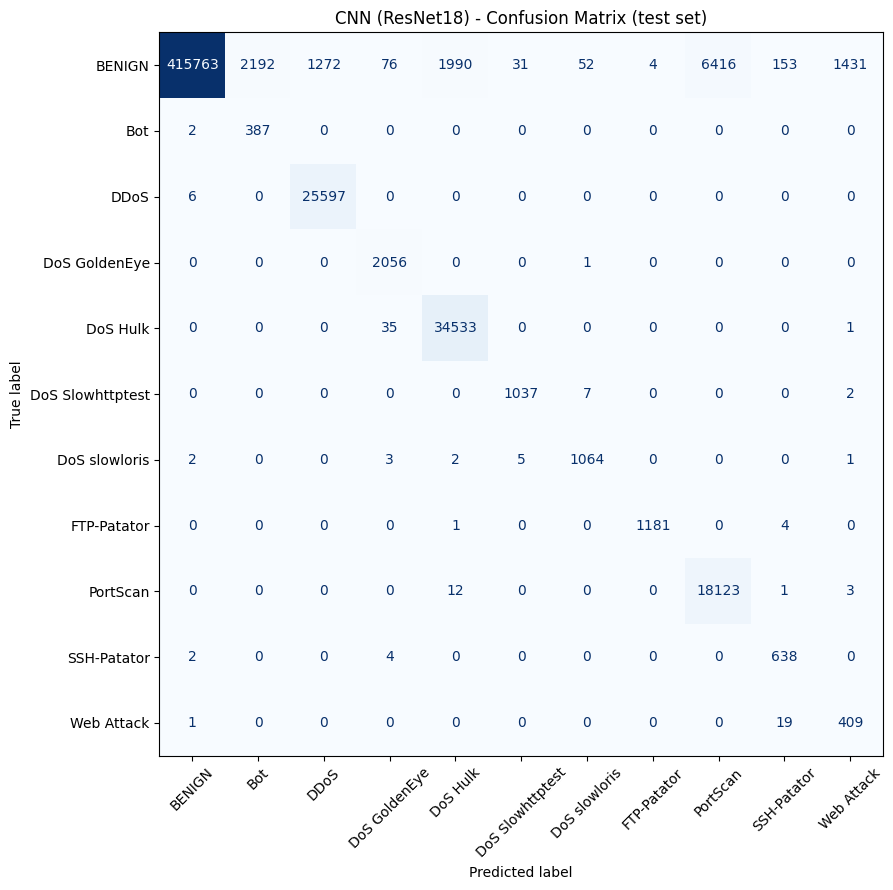

Saved report and confusion matrix.


In [9]:
# --- Evaluar el modelo en el conjunto de test y guardar reportes ---
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

checkpoint = torch.load(MODEL_PATH, map_location=device)
print(f"Loading best checkpoint (epoch {checkpoint['epoch']}, val macro-F1={checkpoint['val_macro_f1']:.4f})")
model.load_state_dict(checkpoint["model_state_dict"])

_, test_true, test_pred = run_epoch(model, test_loader, criterion, device, optimizer=None)

all_labels = np.arange(n_classes)
report_dict = classification_report(test_true, test_pred, labels=all_labels, target_names=class_names,
                                     output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T
CLASSIFICATION_REPORT_CSV = os.path.join(DRIVE_OUTPUT_DIR, "cnn_classification_report.csv")
report_df.to_csv(CLASSIFICATION_REPORT_CSV)

print(classification_report(test_true, test_pred, labels=all_labels, target_names=class_names, zero_division=0))

cm = confusion_matrix(test_true, test_pred, labels=all_labels)
fig, ax = plt.subplots(figsize=(10, 9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("CNN (ResNet18) - Confusion Matrix (test set)")
plt.tight_layout()
CONFUSION_MATRIX_PNG = os.path.join(DRIVE_OUTPUT_DIR, "cnn_confusion_matrix.png")
fig.savefig(CONFUSION_MATRIX_PNG, dpi=150)
plt.show()
print("Saved report and confusion matrix.")


## 10. Where your results are

Everything was already saved to your Google Drive at `My Drive/BDAPP_cnn_results/` as training progressed (checkpoint, training log, plots, report) -- open that folder in Drive directly, no download step needed. (`files.download()` is skipped here for the same reason `files.upload()` was avoided above -- it needs the Colab browser frontend and doesn't work reliably from the VS Code extension.)

Put the files back into your local project at:

- `cnn_resnet18_best.pt` -> `models/`
- `cnn_training_log.csv`, `cnn_classification_report.csv` -> `data/processed/reports/`
- `cnn_training_curves.png`, `cnn_confusion_matrix.png` -> `data/processed/reports/`

(Drag them out of the Drive web UI, or use Drive desktop sync if you have it set up locally.)

In [ ]:
print("Saved in", DRIVE_OUTPUT_DIR, ":")
for fname in sorted(os.listdir(DRIVE_OUTPUT_DIR)):
    fpath = os.path.join(DRIVE_OUTPUT_DIR, fname)
    print(f"  {fname}  ({os.path.getsize(fpath) / 1024:.1f} KB)")